In [4]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_theme(style = "whitegrid")

In [ ]:
def load_dict_per_line(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

beer_advocate = load_dict_per_line('beeradvocate.json')
print("BeerAdvocate shape:", beer_advocate.shape)

rate_beer = load_dict_per_line('ratebeer.json')
print("RateBeer shape:", rate_beer.shape)

In [7]:
def inspect_dataset(df, name):
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    print(f"\n--- First 5 rows ---")
    display(df.head())

    print(f"\n--- Description ---")
    display(df.describe(include='all'))

    print(f"\n--- Column value ranges ---")
    for col in df.columns:
        # Try casting to numeric — some columns look like numbers but are stored as strings
        numeric = pd.to_numeric(df[col], errors='coerce')
        null_count = df[col].isnull().sum()

        if numeric.notna().sum() > 0:
            # Column has numeric content: show min and max
            print(f"  {col:30s}  numeric  |  min: {numeric.min():.4g}  max: {numeric.max():.4g}  |  nulls: {null_count}")
        else:
            # Column is categorical/text: show how many unique values and a few examples
            unique_vals = df[col].dropna().unique()
            sample = list(unique_vals[:3])
            print(f"  {col:30s}  object   |  {df[col].nunique()} unique vals  |  e.g. {sample}  |  nulls: {null_count}")

inspect_dataset(beer_advocate, "BeerAdvocate")
inspect_dataset(rate_beer, "RateBeer")

  BeerAdvocate

--- First 5 rows ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
0,Sausa Weizen,47986,10325,5.00,Hefeweizen,2.5,2,1.5,1.5,1.5,1234817823,stcules,A lot of foam. But a lot.\tIn the smell some b...
1,Red Moon,48213,10325,6.20,English Strong Ale,3,2.5,3,3,3,1235915097,stcules,"Dark red color, light beige foam, average.\tIn..."
2,Black Horse Black Beer,48215,10325,6.50,Foreign / Export Stout,3,2.5,3,3,3,1235916604,stcules,"Almost totally black. Beige foam, quite compac..."
3,Sausa Pils,47969,10325,5.00,German Pilsener,3.5,3,2.5,3,3,1234725145,stcules,"Golden yellow color. White, compact foam, quit..."
4,Cauldron DIPA,64883,1075,7.70,American Double / Imperial IPA,4,4.5,4,4.5,4,1293735206,johnmichaelsen,"According to the website, the style for the Ca..."



--- Description ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
count,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614
unique,56857,66055,5840,531,104,10,9,9,9,10,1577960,33388,1585263
top,90 Minute IPA,2093,35,5.00,American IPA,4,4,4,4,4,1101772800,northyorksammy,
freq,3290,3290,39444,109144,117586,674186,557383,606711,541429,582764,21,5817,353



--- Column value ranges ---
  beer/name                       numeric  |  min: 3  max: 9.021e+04  |  nulls: 1
  beer/beerId                     numeric  |  min: 3  max: 7.732e+04  |  nulls: 1
  beer/brewerId                   numeric  |  min: 1  max: 2.8e+04  |  nulls: 1
  beer/ABV                        numeric  |  min: 0.01  max: 57.7  |  nulls: 1
  beer/style                      object   |  104 unique vals  |  e.g. ['Hefeweizen', 'English Strong Ale', 'Foreign / Export Stout']  |  nulls: 1
  review/appearance               numeric  |  min: 0  max: 5  |  nulls: 1
  review/aroma                    numeric  |  min: 1  max: 5  |  nulls: 1
  review/palate                   numeric  |  min: 1  max: 5  |  nulls: 1
  review/taste                    numeric  |  min: 1  max: 5  |  nulls: 1
  review/overall                  numeric  |  min: 0  max: 5  |  nulls: 1
  review/time                     numeric  |  min: 8.407e+08  max: 1.326e+09  |  nulls: 1
  review/profileName              numeri

,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
0,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,3/5,6/10,13/20,1157587200,hopdog,"On tap at the Springfield, PA location. Poured..."
1,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,4/5,7/10,13/20,1157241600,TomDecapolis,On tap at the John Harvards in Springfield PA....
2,John Harvards Cristal Pilsner,71716,8481,5,Bohemian Pilsener,4/5,5/10,3/5,6/10,14/20,958694400,PhillyBeer2112,"UPDATED: FEB 19, 2003 Springfield, PA. I've ne..."
3,John Harvards Fancy Lawnmower Beer,64125,8481,5.4,Klsch,2/5,4/10,2/5,4/10,8/20,1157587200,TomDecapolis,On tap the Springfield PA location billed as t...
4,John Harvards Fancy Lawnmower Beer,64125,8481,5.4,Klsch,2/5,4/10,2/5,4/10,8/20,1157587200,hopdog,"On tap at the Springfield, PA location. Poured..."



--- Description ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
count,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163
unique,110299,110369,7547,610,89,5,10,5,10,20,4254,29265,2844800
top,Guinness Draught,1267,32,5,India Pale Ale &#40;IPA&#41;,3/5,7/10,3/5,7/10,14/20,1188604800,fonefan,
freq,3696,3696,46566,249966,185953,1269018,868974,1379881,885068,432691,5366,16364,5002



--- Column value ranges ---
  beer/name                       numeric  |  min: 666  max: 666  |  nulls: 1
  beer/beerId                     numeric  |  min: 1  max: 1.634e+05  |  nulls: 1
  beer/brewerId                   numeric  |  min: 1  max: 1.395e+04  |  nulls: 1
  beer/ABV                        numeric  |  min: 0.01  max: 57.7  |  nulls: 1
  beer/style                      object   |  89 unique vals  |  e.g. ['India Pale Ale &#40;IPA&#41;', 'Bohemian Pilsener', 'Klsch']  |  nulls: 1
  review/appearance               object   |  5 unique vals  |  e.g. ['4/5', '2/5', '5/5']  |  nulls: 1
  review/aroma                    object   |  10 unique vals  |  e.g. ['6/10', '5/10', '4/10']  |  nulls: 1
  review/palate                   object   |  5 unique vals  |  e.g. ['3/5', '4/5', '2/5']  |  nulls: 1
  review/taste                    object   |  10 unique vals  |  e.g. ['6/10', '7/10', '4/10']  |  nulls: 1
  review/overall                  object   |  20 unique vals  |  e.g. ['13/20',

In [10]:
# ── Helper: parses both "3.5" and "13/20" into a float ────────────────────────
def parse_rating(val):
    try:
        if '/' in str(val):
            num, denom = val.split('/')
            return float(num) / float(denom)
        return float(val)
    except (ValueError, TypeError):
        return np.nan

# ── Convert rating columns ─────────────────────────────────────────────────────
rating_cols = ['review/appearance', 'review/aroma', 'review/palate',
               'review/taste', 'review/overall']

for col in rating_cols:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col]     = rate_beer[col].apply(parse_rating)

# ── Convert ABV to float ───────────────────────────────────────────────────────
beer_advocate['beer/ABV'] = pd.to_numeric(beer_advocate['beer/ABV'], errors='coerce')
rate_beer['beer/ABV']     = pd.to_numeric(rate_beer['beer/ABV'],     errors='coerce')

# ── Convert timestamps to datetime ─────────────────────────────────────────────
# Guarded with a dtype check so re-running this cell does not crash:
# once the column is already a datetime, .astype(float) would throw a TypeError
if not pd.api.types.is_datetime64_any_dtype(beer_advocate['review/time']):
    beer_advocate['review/time'] = pd.to_datetime(beer_advocate['review/time'].astype(float), unit='s')

if not pd.api.types.is_datetime64_any_dtype(rate_beer['review/time']):
    rate_beer['review/time'] = pd.to_datetime(rate_beer['review/time'].astype(float), unit='s')

# ── Range of review/overall ───────────────────────────────────────────────────
print(f"{'Dataset':<20} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 46)
for df, name in [(beer_advocate, 'BeerAdvocate'), (rate_beer, 'RateBeer')]:
    col = df['review/overall']
    print(f"{name:<20} {col.min():>8.3f} {col.max():>8.3f} {col.mean():>8.3f}")


Dataset                   Min      Max     Mean
----------------------------------------------
BeerAdvocate            0.000    5.000    3.816
RateBeer                0.050    1.000    0.660


In [11]:
# BeerAdvocate ratings are 0–5 floats, so we divide by 5 to bring them to 0–1.
# RateBeer ratings are already 0–1 after fraction parsing (e.g. 13/20 = 0.65), so no change needed.

beer_advocate[rating_cols] = beer_advocate[rating_cols] / 5

# Sanity check — both datasets should now have review/overall in [0, 1]
print(f"{'Dataset':<20} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 46)
for df, name in [(beer_advocate, 'BeerAdvocate'), (rate_beer, 'RateBeer')]:
    col = df['review/overall']
    print(f"{name:<20} {col.min():>8.3f} {col.max():>8.3f} {col.mean():>8.3f}")

print("\n--- BeerAdvocate head ---")
display(beer_advocate[['beer/name', 'beer/style', 'review/appearance', 'review/aroma',
                        'review/palate', 'review/taste', 'review/overall',
                        'review/profileName', 'review/time']].head())

print("\n--- RateBeer head ---")
display(rate_beer[['beer/name', 'beer/style', 'review/appearance', 'review/aroma',
                   'review/palate', 'review/taste', 'review/overall',
                   'review/profileName', 'review/time']].head())

Dataset                   Min      Max     Mean
----------------------------------------------
BeerAdvocate            0.000    1.000    0.763
RateBeer                0.050    1.000    0.660

--- BeerAdvocate head ---


,beer/name,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/profileName,review/time
0,Sausa Weizen,Hefeweizen,0.5,0.4,0.3,0.3,0.3,stcules,2009-02-16 20:57:03
1,Red Moon,English Strong Ale,0.6,0.5,0.6,0.6,0.6,stcules,2009-03-01 13:44:57
2,Black Horse Black Beer,Foreign / Export Stout,0.6,0.5,0.6,0.6,0.6,stcules,2009-03-01 14:10:04
3,Sausa Pils,German Pilsener,0.7,0.6,0.5,0.6,0.6,stcules,2009-02-15 19:12:25
4,Cauldron DIPA,American Double / Imperial IPA,0.8,0.9,0.8,0.9,0.8,johnmichaelsen,2010-12-30 18:53:26



--- RateBeer head ---


,beer/name,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/profileName,review/time
0,John Harvards Simcoe IPA,India Pale Ale &#40;IPA&#41;,0.8,0.6,0.6,0.6,0.65,hopdog,2006-09-07
1,John Harvards Simcoe IPA,India Pale Ale &#40;IPA&#41;,0.8,0.6,0.8,0.7,0.65,TomDecapolis,2006-09-03
2,John Harvards Cristal Pilsner,Bohemian Pilsener,0.8,0.5,0.6,0.6,0.70,PhillyBeer2112,2000-05-19
3,John Harvards Fancy Lawnmower Beer,Klsch,0.4,0.4,0.4,0.4,0.40,TomDecapolis,2006-09-07
4,John Harvards Fancy Lawnmower Beer,Klsch,0.4,0.4,0.4,0.4,0.40,hopdog,2006-09-07


In [12]:
# ── Add source label ───────────────────────────────────────────────────────────
# Tag every row so we know which platform it came from after combining
beer_advocate['source'] = 'beeradvocate'
rate_beer['source']     = 'ratebeer'

# ── Combine ────────────────────────────────────────────────────────────────────
# axis=0 stacks rows vertically (as opposed to axis=1 which adds columns side by side)
# ignore_index=True resets the index to 0, 1, 2, ... for the combined DataFrame,
# otherwise you'd have duplicate index values from both datasets
df = pd.concat([beer_advocate, rate_beer], axis=0, ignore_index=True)

print("Combined shape:", df.shape)
print("\nReviews per source:")
print(df['source'].value_counts())
print("\nColumn dtypes:")
print(df.dtypes)


Combined shape: (4510779, 14)

Reviews per source:
ratebeer        2924164
beeradvocate    1586615
Name: source, dtype: int64

Column dtypes:
beer/name                     object
beer/beerId                   object
beer/brewerId                 object
beer/ABV                     float64
beer/style                    object
review/appearance            float64
review/aroma                 float64
review/palate                float64
review/taste                 float64
review/overall               float64
review/time           datetime64[ns]
review/profileName            object
review/text                   object
source                        object
dtype: object


In [14]:
# ── Create unique item ID ─────────────────────────────────────────────────────
# beer/beerId values are platform-specific and overlap — both platforms start
# from 1, so beer_id '100' on BeerAdvocate and '100' on RateBeer are different beers.
# Prefixing with the source makes each ID globally unique across the combined dataset.
df['item_id'] = df['source'] + '_' + df['beer/beerId'].astype(str)

print('Unique items:', df['item_id'].nunique())
print('Unique users:', df['review/profileName'].nunique())
print('\nSample item IDs:')
print(df['item_id'].head(10).values)


Unique items: 176426
Unique users: 60786

Sample item IDs:
['beeradvocate_47986' 'beeradvocate_48213' 'beeradvocate_48215'
 'beeradvocate_47969' 'beeradvocate_64883' 'beeradvocate_52159'
 'beeradvocate_52159' 'beeradvocate_52159' 'beeradvocate_52159'
 'beeradvocate_52159']


In [15]:
# ── Missing values ────────────────────────────────────────────────────────────
# For a recommender we only strictly need three things per row: a user, an item,
# and a rating. We check all columns for completeness but only drop rows where
# one of those three is missing — everything else we can live with.
print('--- Null counts ---')
print(df.isnull().sum())

core_cols = ['review/profileName', 'item_id', 'review/overall']
before = len(df)
df = df.dropna(subset=core_cols)
after = len(df)
print(f'\nRows dropped due to missing user / item / rating: {before - after}')
print(f'Rows remaining: {after}')

# ── Duplicate reviews ─────────────────────────────────────────────────────────
# A duplicate here means the same user reviewed the same beer more than once
# on the same platform. This is a problem for a recommender because the
# user-item matrix expects one rating per (user, item) pair.
dupes = df.duplicated(subset=['review/profileName', 'item_id'])
print(f'\nDuplicate (user, item) pairs: {dupes.sum()}')

# Keep the first review and drop the rest
df = df.drop_duplicates(subset=['review/profileName', 'item_id'], keep='first')
print(f'Rows after dropping duplicates: {len(df)}')


--- Null counts ---
beer/name                  2
beer/beerId                2
beer/brewerId              2
beer/ABV              206424
beer/style                 2
review/appearance          2
review/aroma               2
review/palate              2
review/taste               2
review/overall             2
review/time                2
review/profileName         2
review/text                2
source                     0
item_id                    0
dtype: int64

Rows dropped due to missing user / item / rating: 2
Rows remaining: 4510777

Duplicate (user, item) pairs: 83737
Rows after dropping duplicates: 4427040


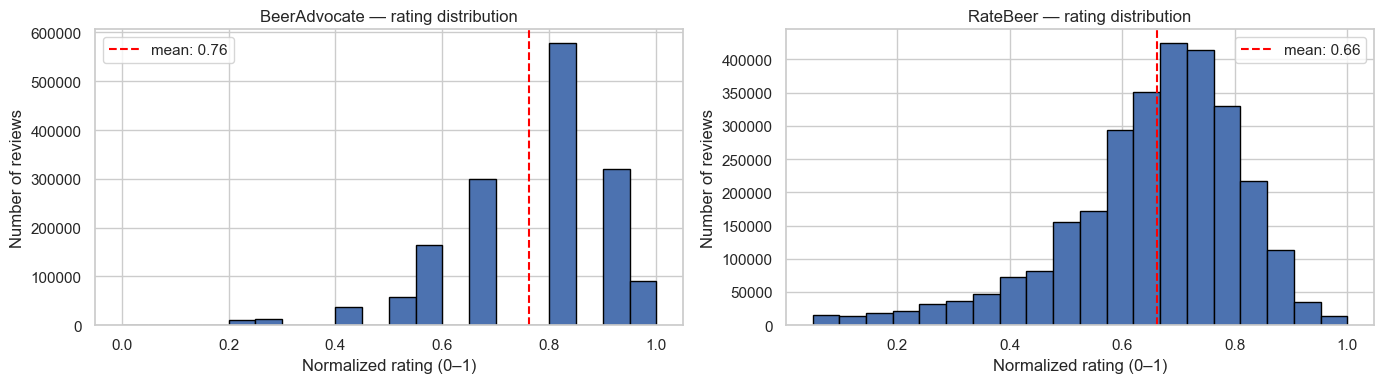

                  count   mean    std   min  25%  50%   75%  max
source                                                          
beeradvocate  1571808.0  0.763  0.144  0.00  0.7  0.8  0.90  1.0
ratebeer      2855232.0  0.662  0.166  0.05  0.6  0.7  0.75  1.0


In [16]:
# ── Rating Distribution ───────────────────────────────────────────────────────
# We plot both platforms side by side so we can visually compare the shape.
# A healthy rating distribution for a recommender should have spread across
# the scale — if everyone gives 1.0, the ratings carry no useful signal.

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, (src, label) in zip(axes, [('beeradvocate', 'BeerAdvocate'), ('ratebeer', 'RateBeer')]):
    subset = df[df['source'] == src]['review/overall']
    ax.hist(subset, bins=20, edgecolor='black')
    ax.set_title(f'{label} — rating distribution')
    ax.set_xlabel('Normalized rating (0–1)')
    ax.set_ylabel('Number of reviews')
    ax.axvline(subset.mean(), color='red', linestyle='--', label=f'mean: {subset.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

print(df.groupby('source')['review/overall'].describe().round(3))


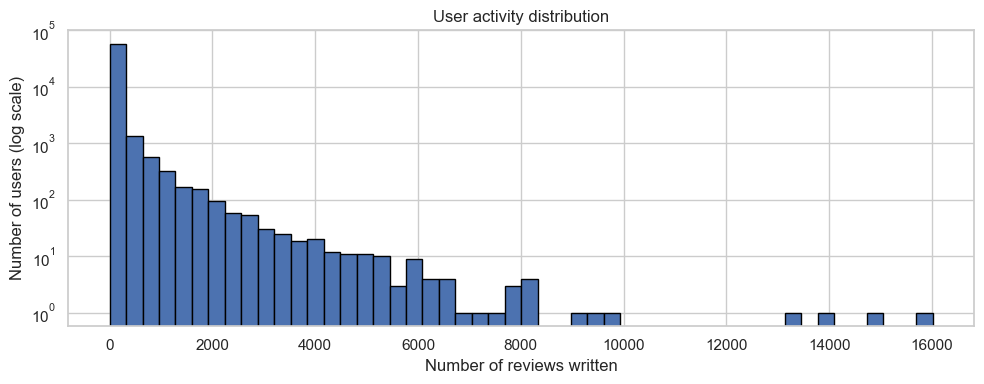

count    60786.0
mean        72.8
std        350.5
min          1.0
25%          1.0
50%          3.0
75%         17.0
max      16015.0
Name: review_count, dtype: float64
Users with <=  1 reviews: 19,265  (31.7%)
Users with <=  5 reviews: 36,187  (59.5%)
Users with <= 10 reviews: 42,199  (69.4%)


In [17]:
# ── User Activity Distribution ────────────────────────────────────────────────
# Count how many reviews each user has written.
# In almost every real-world dataset this follows a power law — a small number
# of very active users account for the majority of reviews, while most users
# have only written a handful. We use a log scale on the y-axis to make this
# shape visible (otherwise the tall bar at low counts dominates the chart).

user_activity = df.groupby('review/profileName').size().rename('review_count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_activity, bins=50, log=True, edgecolor='black')
ax.set_xlabel('Number of reviews written')
ax.set_ylabel('Number of users (log scale)')
ax.set_title('User activity distribution')
plt.tight_layout()
plt.show()

print(user_activity.describe().round(1))

# Cold-start users: users with very few reviews are hard for a recommender
# to make good predictions for because there is not enough signal to learn from
for threshold in [1, 5, 10]:
    n = (user_activity <= threshold).sum()
    pct = 100 * n / len(user_activity)
    print(f'Users with <= {threshold:>2} reviews: {n:>6,}  ({pct:.1f}%)')


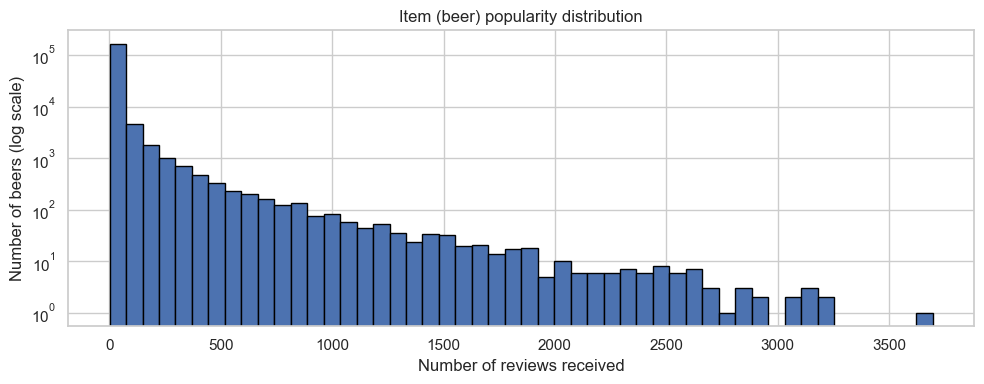

count    176424.0
mean         25.1
std         109.6
min           1.0
25%           1.0
50%           3.0
75%          11.0
max        3696.0
Name: review_count, dtype: float64
Beers with <=  1 reviews: 48,602  (27.5%)
Beers with <=  5 reviews: 108,603  (61.6%)
Beers with <= 10 reviews: 130,976  (74.2%)


In [18]:
# ── Item Popularity Distribution ──────────────────────────────────────────────
# Count how many reviews each beer has received.
# Same power law shape expected — a few famous beers have thousands of reviews,
# most beers have very few. Beers with very few reviews are cold-start items.

item_popularity = df.groupby('item_id').size().rename('review_count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(item_popularity, bins=50, log=True, edgecolor='black')
ax.set_xlabel('Number of reviews received')
ax.set_ylabel('Number of beers (log scale)')
ax.set_title('Item (beer) popularity distribution')
plt.tight_layout()
plt.show()

print(item_popularity.describe().round(1))

# Cold-start items
for threshold in [1, 5, 10]:
    n = (item_popularity <= threshold).sum()
    pct = 100 * n / len(item_popularity)
    print(f'Beers with <= {threshold:>2} reviews: {n:>6,}  ({pct:.1f}%)')


In [19]:
# ── Sparsity ──────────────────────────────────────────────────────────────────
# The user-item matrix has one row per user and one column per item.
# Each cell would hold a rating — but most users have only reviewed a tiny
# fraction of all beers, so most cells are empty. Sparsity measures how
# empty the matrix is. 99% sparsity means only 1% of cells have a rating.

n_users        = df['review/profileName'].nunique()
n_items        = df['item_id'].nunique()
n_interactions = len(df)
possible       = n_users * n_items
sparsity       = 1 - (n_interactions / possible)

print(f'Users:             {n_users:>10,}')
print(f'Items:             {n_items:>10,}')
print(f'Interactions:      {n_interactions:>10,}')
print(f'Possible pairs:    {possible:>10,}')
print(f'Sparsity:          {sparsity:>10.4%}')


Users:                 60,786
Items:                176,424
Interactions:       4,427,040
Possible pairs:    10,724,109,264
Sparsity:            99.9587%


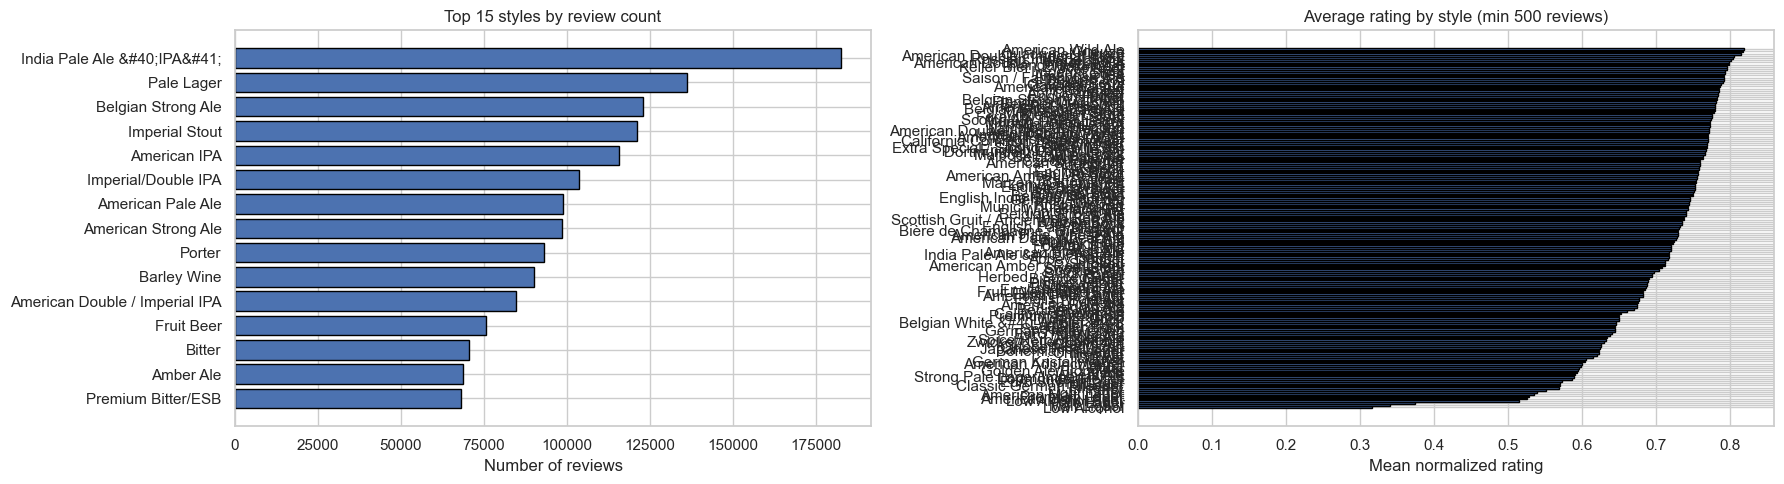

Total unique styles: 179


In [20]:
# ── Beer Style Distribution ───────────────────────────────────────────────────
# Style is a content feature we can use later in the recommender (content-based
# filtering). Here we check which styles dominate the dataset and whether
# average rating varies meaningfully by style — if it does, style carries signal.

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Plot 1: top 15 styles by review count -----------------------------------
top_styles = df['beer/style'].value_counts().head(15)
axes[0].barh(top_styles.index[::-1], top_styles.values[::-1], edgecolor='black')
axes[0].set_xlabel('Number of reviews')
axes[0].set_title('Top 15 styles by review count')

# --- Plot 2: average normalized rating per style (min 500 reviews) -----------
# We filter to styles with at least 500 reviews so the averages are reliable
style_ratings = (
    df.groupby('beer/style')['review/overall']
    .agg(mean_rating='mean', review_count='count')
    .query('review_count >= 500')
    .sort_values('mean_rating', ascending=True)
)
axes[1].barh(style_ratings.index, style_ratings['mean_rating'], edgecolor='black')
axes[1].set_xlabel('Mean normalized rating')
axes[1].set_title('Average rating by style (min 500 reviews)')

plt.tight_layout()
plt.show()

print(f'Total unique styles: {df["beer/style"].nunique()}')


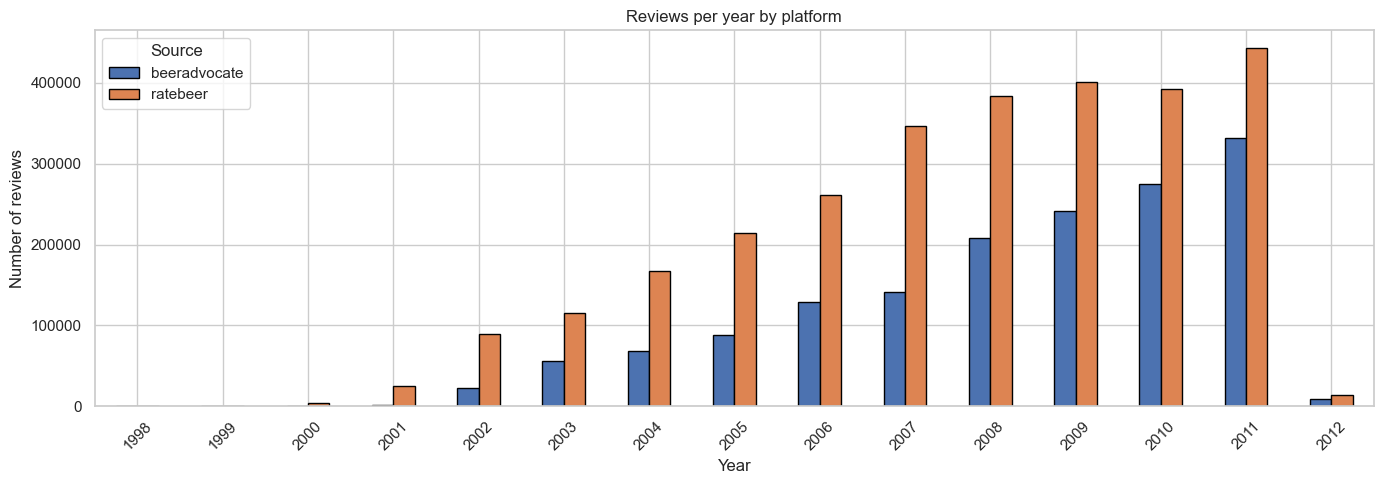

source  beeradvocate  ratebeer
year                          
1998             132         0
1999              83         0
2000             115      4414
2001            1950     24856
2002           22622     89336
2003           55944    114787
2004           68704    167869
2005           88109    214570
2006          128435    261665
2007          141059    346204
2008          208000    383055
2009          241087    400522
2010          274796    391981
2011          331123    442582
2012            9649     13391


In [21]:
# ── Temporal Analysis ─────────────────────────────────────────────────────────
# We extract the year from the datetime column and count reviews per year
# per platform. This tells us:
#   - whether the data is stale (old reviews may not reflect current tastes)
#   - whether the two platforms grew or shrank at different rates
#   - if there are any suspicious spikes or gaps worth investigating

df['year'] = df['review/time'].dt.year

reviews_per_year = (
    df.groupby(['year', 'source'])
    .size()
    .unstack(fill_value=0)  # pivot source into columns so we get one bar per platform per year
)

reviews_per_year.plot(kind='bar', figsize=(14, 5), edgecolor='black')
plt.title('Reviews per year by platform')
plt.xlabel('Year')
plt.ylabel('Number of reviews')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()

print(reviews_per_year)
